In [1]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt

class MembershipInferenceAttack:
    """
    A class to represent a membership inference attack.
    
    This class is used to perform membership inference attacks on machine learning models.
    It can be extended to implement specific attack strategies.
    """
    
    def __init__(self, target_model, num_classes= 4):
        """
        Initializes the MembershipInferenceAttack with a given model.
        
        :param model: The machine learning model to attack.
        """
        self.target_model = target_model
        self.num_classes = num_classes

    def extract_features(self, data, labels):
        predictions = self.target_model.predict(data, verbose=0)
        
        features = []
        
        for i, (pred, true_label) in enumerate(zip(predictions, labels)):
            # Flatten predictions for pixel-wise analysis
            pred_flat = pred.reshape(-1, self.num_classes)
            true_flat = true_label.flatten() if len(true_label.shape) > 1 else true_label.reshape(-1)
            
            # Feature 1: Maximum confidence (averaged over all pixels)
            max_confidence = np.mean(np.max(pred_flat, axis=1))
            
            # Feature 2: Entropy (measure of uncertainty)
            entropy = -np.mean(np.sum(pred_flat * np.log(pred_flat + 1e-8), axis=1))
            
            # Feature 3: Cross-entropy loss
            ce_loss = -np.mean(np.sum(tf.one_hot(true_flat, self.num_classes) * np.log(pred_flat + 1e-8), axis=1))
            
            # Feature 4: Prediction accuracy (pixel-wise)
            pred_labels = np.argmax(pred_flat, axis=1)
            accuracy = np.mean(pred_labels == true_flat)
            
            # Feature 5: Top-2 confidence gap
            sorted_probs = np.sort(pred_flat, axis=1)
            confidence_gap = np.mean(sorted_probs[:, -1] - sorted_probs[:, -2])
            
            # Feature 6: Variance of predictions
            pred_variance = np.var(pred_flat, axis=1).mean()
            
            # Feature 7: Mean probability of true class
            true_class_prob = np.mean([pred_flat[j, true_flat[j]] for j in range(len(true_flat))])
            
            features.append([
                max_confidence, entropy, ce_loss, accuracy, 
                confidence_gap, pred_variance, true_class_prob
            ])
        
        return np.array(features)
    
    def prepare_attack_dataset(self, member_data, member_labels, non_member_data, non_member_labels):
        """
        Prepare dataset for training the attack model
        """
        print("Extracting features from member data...")
        member_features = self.extract_features(member_data, member_labels)
        member_labels_binary = np.ones(len(member_features))  # 1 = member
        
        print("Extracting features from non-member data...")
        non_member_features = self.extract_features(non_member_data, non_member_labels)
        non_member_labels_binary = np.zeros(len(non_member_features))  # 0 = non-member
        
        # Combine datasets
        X = np.vstack([member_features, non_member_features])
        y = np.hstack([member_labels_binary, non_member_labels_binary])
        
        return X, y
    
    def train_attack_model(self, X, y, test_size=0.3):
        """
        Train the attack model to predict membership
        """
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
        
        # Use Random Forest as attack model (simple and effective)
        self.attack_model = RandomForestClassifier(n_estimators=100, random_state=42)
        self.attack_model.fit(X_train, y_train)
        
        # Evaluate attack performance
        y_pred = self.attack_model.predict(X_test)
        y_pred_proba = self.attack_model.predict_proba(X_test)[:, 1]
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        print(f"Attack Model Performance:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"AUC: {auc:.4f}")
        
        # Feature importance
        feature_names = ['Max Confidence', 'Entropy', 'CE Loss', 'Accuracy', 
                        'Confidence Gap', 'Pred Variance', 'True Class Prob']
        
        importance = self.attack_model.feature_importances_
        for name, imp in zip(feature_names, importance):
            print(f"{name}: {imp:.4f}")
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'feature_importance': dict(zip(feature_names, importance))
        }

    def enhanced_attack_with_gradients(self, data, labels):
        """
        Enhanced attack using gradient information
        This exploits the model's gradient behavior for member vs non-member data
        """
        features = []
        
        for i, (sample, label) in enumerate(zip(data, labels)):
            sample_batch = np.expand_dims(sample, axis=0)
            label_batch = np.expand_dims(label, axis=0)
            
            with tf.GradientTape() as tape:
                tape.watch(sample_batch)
                predictions = self.target_model(sample_batch, training=False)
                loss = tf.keras.losses.sparse_categorical_crossentropy(label_batch, predictions)
            
            # Get gradients
            gradients = tape.gradient(loss, sample_batch)
            
            # Extract gradient-based features
            grad_norm = tf.norm(gradients).numpy()
            grad_mean = tf.reduce_mean(tf.abs(gradients)).numpy()
            grad_std = tf.math.reduce_std(gradients).numpy()
            
            # Combine with prediction-based features
            pred_features = self.extract_features(sample_batch, label_batch)[0]
            
            enhanced_features = np.concatenate([pred_features, [grad_norm, grad_mean, grad_std]])
            features.append(enhanced_features)
        
        return np.array(features)

2025-08-14 22:02:00.077459: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-14 22:02:00.146497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755189120.189730    1831 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755189120.200955    1831 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755189120.244333    1831 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
class PrivacyAnalyzer:
    """
    Analyze privacy vulnerabilities in the model
    """
    
    def __init__(self, model):
        self.model = model
    
    def analyze_overfitting_indicators(self, train_data, val_data):
        """
        Analyze overfitting which can lead to membership inference vulnerabilities
        """
        train_loss = self.model.evaluate(train_data[0], train_data[1], verbose=0)[0]
        val_loss = self.model.evaluate(val_data[0], val_data[1], verbose=0)[0]
        
        overfitting_ratio = val_loss / train_loss
        
        print(f"Training Loss: {train_loss:.4f}")
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Overfitting Ratio: {overfitting_ratio:.4f}")
        
        if overfitting_ratio > 1.2:
            print("WARNING: Significant overfitting detected - high MIA risk!")
        elif overfitting_ratio > 1.1:
            print("CAUTION: Moderate overfitting - potential MIA risk")
        else:
            print("INFO: Low overfitting - reduced MIA risk")
        
        return overfitting_ratio
    
    def confidence_distribution_analysis(self, member_data, non_member_data):
        """
        Analyze confidence distributions between members and non-members
        """
        member_preds = self.model.predict(member_data, verbose=0)
        non_member_preds = self.model.predict(non_member_data, verbose=0)
        
        # Calculate confidence scores
        member_confidence = np.max(member_preds.reshape(-1, member_preds.shape[-1]), axis=1)
        non_member_confidence = np.max(non_member_preds.reshape(-1, non_member_preds.shape[-1]), axis=1)
        
        # Statistical analysis
        member_mean = np.mean(member_confidence)
        non_member_mean = np.mean(non_member_confidence)
        
        print(f"Member confidence mean: {member_mean:.4f}")
        print(f"Non-member confidence mean: {non_member_mean:.4f}")
        print(f"Confidence gap: {member_mean - non_member_mean:.4f}")
        
        if abs(member_mean - non_member_mean) > 0.05:
            print("WARNING: Large confidence gap detected - vulnerable to MIA!")
        
        return member_confidence, non_member_confidence

In [4]:
def plot_feature_importance(feature_importance):
    feature_names = list(feature_importance.keys())
    importances = list(feature_importance.values())
    plt.figure(figsize=(10, 6))
    plt.bar(feature_names, importances)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Feature Importance in Membership Inference Attack')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def run_membership_inference_attack(target_model, train_data, test_data, shadow_data=None):
    """
    Complete MIA pipeline
    """
    print("="*50)
    print("MEMBERSHIP INFERENCE ATTACK ANALYSIS")
    print("="*50)
    
    # Initialize attack
    mia = MembershipInferenceAttack(target_model)
    
    # Use training data as members and test data as non-members
    member_data, member_labels = train_data
    non_member_data, non_member_labels = test_data
    
    # Prepare attack dataset
    X, y = mia.prepare_attack_dataset(member_data, member_labels, 
                                     non_member_data, non_member_labels)
    
    # Train attack model
    results = mia.train_attack_model(X, y)

    print(results)
    
    # Privacy analysis
    print("\n" + "="*30)
    print("PRIVACY VULNERABILITY ANALYSIS")
    print("="*30)
    
    analyzer = PrivacyAnalyzer(target_model)
    overfitting_ratio = analyzer.analyze_overfitting_indicators(train_data, test_data)
    
    print("\nConfidence Distribution Analysis:")
    member_conf, non_member_conf = analyzer.confidence_distribution_analysis(
        member_data[:100], non_member_data[:100]  # Sample for efficiency
    )
    
    # Risk assessment
    print("\n" + "="*30)
    print("RISK ASSESSMENT")
    print("="*30)
    
    attack_accuracy = results['accuracy']

    plot_feature_importance(results['feature_importance'])
    
    if attack_accuracy > 0.7:
        risk_level = "HIGH"
        print(f"🔴 {risk_level} RISK: Attack accuracy {attack_accuracy:.3f} - Model is vulnerable!")
    elif attack_accuracy > 0.6:
        risk_level = "MEDIUM"
        print(f"🟡 {risk_level} RISK: Attack accuracy {attack_accuracy:.3f} - Some vulnerability exists")
    else:
        risk_level = "LOW"
        print(f"🟢 {risk_level} RISK: Attack accuracy {attack_accuracy:.3f} - Model appears robust")
    
    return results, risk_level

In [5]:
from data_loader import DataLoader
data_loader = DataLoader()
image_dir = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images'
label_dir = '/home/yasas/GazeEstimation/openEDS/openEDS/train/labels'
images, labels = data_loader.load_images_label_pairs(image_dir, label_dir, step=1, step_size=2000, add_noise=True)
if images is None or labels is None:
    raise ValueError("Images and labels must be loaded before running the attack.")

Images count: 27431


In [ ]:
from privacy_preserving_unet_model import PrivacyPreservingUNet
from sklearn.model_selection import train_test_split

target_model = PrivacyPreservingUNet.load_model('privacy_preserving_unet_high.h5')

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.5, random_state=42)

run_membership_inference_attack(target_model, (img_train, label_train), (img_test, label_test))

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'privacy_preserving_high.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

MEMBERSHIP INFERENCE ATTACK ANALYSIS
Extracting features from member data...


I0000 00:00:1754325670.250054  275354 service.cc:152] XLA service 0x2e0701f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754325670.251110  275354 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-08-04 22:11:10.410380: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754325670.752280  275354 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-08-04 22:11:15.387558: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8', 416 bytes spill stores, 412 bytes spill loads

2025-08-04 22:11:16.520703: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot

Extracting features from non-member data...


2025-08-04 22:12:18.240382: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 1408 bytes spill stores, 1356 bytes spill loads

2025-08-04 22:12:18.761819: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 380 bytes spill stores, 380 bytes spill loads

2025-08-04 22:12:19.807321: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9', 2612 bytes spill stores, 4424 bytes spill loads

2025-08-04 22:12:19.957197: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 1512 bytes spill stores, 1500 bytes spill loads

2025-08-04 22:12:20.433653: I external

Attack Model Performance:
Accuracy: 0.7800
Precision: 0.8223
Recall: 0.9333
Max Confidence: 0.1419
Entropy: 0.1437
CE Loss: 0.1473
Accuracy: 0.1363
Confidence Gap: 0.1430
Pred Variance: 0.1427
True Class Prob: 0.1451
{'accuracy': 0.78, 'precision': 0.8223495702005731, 'recall': 0.9333333333333333, 'feature_importance': {'Max Confidence': 0.1419300578155212, 'Entropy': 0.14366947422653378, 'CE Loss': 0.14730305757064324, 'Accuracy': 0.13634959559222581, 'Confidence Gap': 0.14303057094052984, 'Pred Variance': 0.14266453825944372, 'True Class Prob': 0.14505270559510247}}

PRIVACY VULNERABILITY ANALYSIS


2025-08-04 22:12:34.574967: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-08-04 22:12:39.721322: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-08-04 22:12:43.092358: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


Training Loss: 0.1960
Validation Loss: 0.1963
Overfitting Ratio: 1.0014
INFO: Low overfitting - reduced MIA risk

Confidence Distribution Analysis:


2025-08-04 22:12:50.151246: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 592 bytes spill stores, 500 bytes spill loads

2025-08-04 22:12:50.932663: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 672 bytes spill stores, 544 bytes spill loads

2025-08-04 22:12:51.048356: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8_0', 388 bytes spill stores, 388 bytes spill loads

2025-08-04 22:12:52.623728: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9_0', 132 bytes spill stores, 132 bytes spill loads

2025-08-04 22:12:53.471321: I external/l

Member confidence mean: 0.9422
Non-member confidence mean: 0.9433
Confidence gap: -0.0011

RISK ASSESSMENT


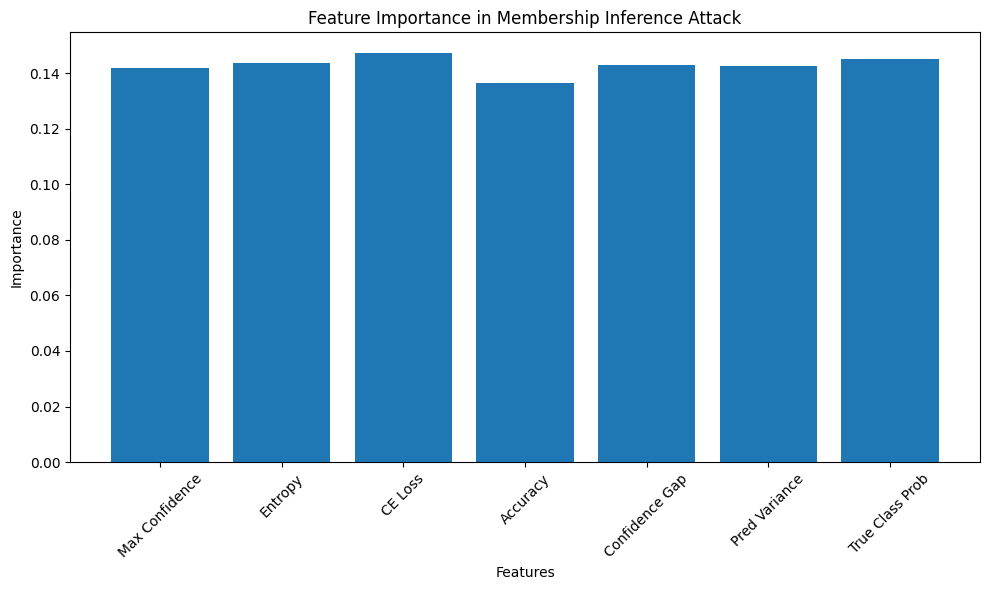

🔴 HIGH RISK: Attack accuracy 0.780 - Model is vulnerable!


({'accuracy': 0.78,
  'precision': 0.8223495702005731,
  'recall': 0.9333333333333333,
  'feature_importance': {'Max Confidence': 0.1419300578155212,
   'Entropy': 0.14366947422653378,
   'CE Loss': 0.14730305757064324,
   'Accuracy': 0.13634959559222581,
   'Confidence Gap': 0.14303057094052984,
   'Pred Variance': 0.14266453825944372,
   'True Class Prob': 0.14505270559510247}},
 'HIGH')

In [6]:
from privacy_preserving_unet_model import PrivacyPreservingUNet

target_model = PrivacyPreservingUNet.load_model('privacy_preserving_unet_medium_5.h5')

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)

run_membership_inference_attack(target_model, (img_train, label_train), (img_test, label_test))